# Syllable entropy per timebin over the course of a trial

Loads the current syllable format (`{k}_k_{L}_bin_syllables_<date>`, saved by
`segmentation/5_syllable_generation.ipynb`), reconstructs each trial as an
epoch-ordered sequence of `L`-binned syllable codes, and computes the Shannon
entropy of syllable use at each timebin across the trial.

Syllable code `s` encodes three behaviours: `paw = s % n_paw_states`,
`whisk = (s // n_paw_states) % 2`, `lick = s // (2 * n_paw_states)`.

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy as shannon_entropy

prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'
base_path = prefix + 'representation_learning_variability/paper-individuality/data/'

## Load data (current format)

In [110]:
# ---- Parameters ----
filename = base_path + '8_k_10_bin_syllables_06-07-2026'
n_paw_states = 8                       # paw clusters; total syllables = 2 * 2 * n_paw_states
n_syllables = 4 * n_paw_states         # whisk (2) x lick (2) x paw
target_length = 10                     # bins per epoch (the L in the filename)
epoch_order = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']  # chronological within a trial

all_sequences = pd.read_parquet(filename)
all_sequences['session'] = all_sequences['sample'].str[:36]
print(f"{all_sequences['mouse_name'].nunique()} mice, "
      f"{all_sequences['session'].nunique()} sessions loaded")

102 mice, 318 sessions loaded


In [111]:
# Same session/mouse QC as the LDA pipeline, so results are comparable
prob_sessions = [
    '30af8629-7b96-45b7-8778-374720ddbc5e', '90e524a2-aa63-47ce-b5b8-1b1941a1223a',
    'a8a8af78-16de-4841-ab07-fde4b5281a03', '49368f16-de69-4647-9a7a-761e94517821',
    'a71175be-d1fd-47a3-aa93-b830ea3634a1', '0deb75fb-9088-42d9-b744-012fb8fc4afb',
    '02fbb6da-3034-47d6-a61b-7d06c796a830', '7f6b86f9-879a-4ea2-8531-294a221af5d0',
    '8c33abef-3d3e-4d42-9f27-445e9def08f9', 'ebe2efe3-e8a1-451a-8947-76ef42427cc9',
    '510b1a50-825d-44ce-86f6-9678f5396e02']

all_sequences = all_sequences.loc[~all_sequences['session'].isin(prob_sessions)].reset_index(drop=True)

session_count = (all_sequences[['mouse_name', 'session']].drop_duplicates()
                 .groupby('mouse_name')['session'].count())
multi_sess_mice = session_count[session_count > 2].index
all_sequences = all_sequences.loc[all_sequences['mouse_name'].isin(multi_sess_mice)].reset_index(drop=True)
print(f"After QC: {all_sequences['mouse_name'].nunique()} mice, "
      f"{all_sequences['session'].nunique()} sessions")

After QC: 56 mice, 248 sessions


## Reconstruct each trial as a 40-timebin syllable sequence

In [112]:
# One row per trial; columns are the epochs, each holding a length-L syllable array
design_df = (all_sequences
             .pivot(index=['mouse_name', 'session', 'sample', 'trial_type'],
                    columns='broader_label', values='binned_sequence')
             .reset_index()
             .dropna())

# Concatenate epochs in chronological order -> (n_trials, n_epochs * target_length)
trial_seqs = np.vstack(design_df[epoch_order].apply(lambda row: np.hstack(row), axis=1))
n_timebins = trial_seqs.shape[1]
assert n_timebins == len(epoch_order) * target_length
print(f"{trial_seqs.shape[0]} trials x {n_timebins} timebins")

154433 trials x 40 timebins


## Entropy of syllable use per timebin

For each session and each timebin we take the distribution of syllable codes across
that session's trials and compute its Shannon entropy (bits). We then summarise across
sessions (mean ± SEM). High entropy = many different syllables used at that point in
the trial; low entropy = the behaviour is stereotyped.

In [113]:
def timebin_entropy(codes, n_categories):
    """Shannon entropy (bits) of a categorical distribution, ignoring NaNs."""
    codes = codes[~np.isnan(codes)].astype(int)
    if codes.size == 0:
        return np.nan
    counts = np.bincount(codes, minlength=n_categories)
    return shannon_entropy(counts, base=2)


def entropy_per_timebin(seqs, decode, n_categories):
    """Per-timebin entropy of the (optionally decoded) syllable stream."""
    return np.array([timebin_entropy(decode(seqs[:, t]), n_categories)
                     for t in range(seqs.shape[1])])


# Marginal decoders: full syllable vs. its paw / whisk / lick components
components = {
    'Syllable': (lambda x: x, n_syllables),
    'Paw':      (lambda x: x % n_paw_states, n_paw_states),
    'Whisk':    (lambda x: (x // n_paw_states) % 2, 2),
    'Lick':     (lambda x: x // (2 * n_paw_states), 2),
}

sessions = design_df['session'].values
# entropy_by_comp[comp] -> (n_sessions, n_timebins)
entropy_by_comp = {c: [] for c in components}
for sess in pd.unique(sessions):
    sub = trial_seqs[sessions == sess]
    for comp, (decode, ncat) in components.items():
        # decode preserves NaNs (nan % k = nan, nan // k = nan)
        entropy_by_comp[comp].append(entropy_per_timebin(sub, decode, ncat))
entropy_by_comp = {c: np.array(v) for c, v in entropy_by_comp.items()}
print('sessions x timebins:', entropy_by_comp['Syllable'].shape)

sessions x timebins: (248, 40)


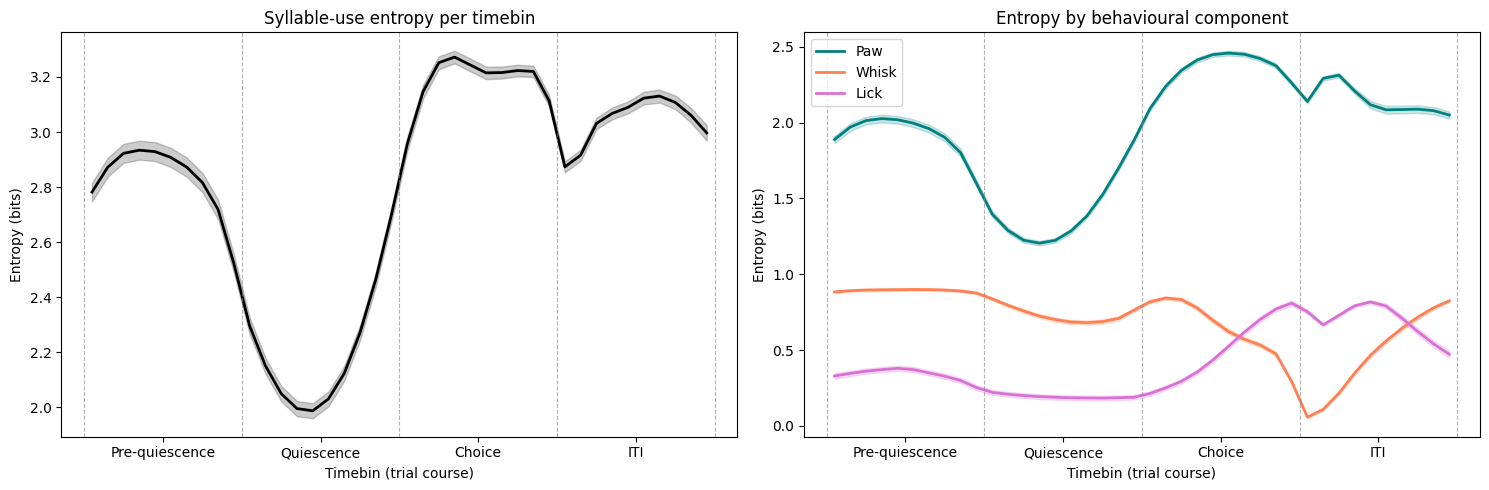

In [114]:
# ---- Plot: entropy across the trial, mean +/- SEM over sessions ----
x = np.arange(n_timebins)
epoch_bounds = np.arange(0, n_timebins + 1, target_length)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Left: full syllable entropy
H = entropy_by_comp['Syllable']
m, se = np.nanmean(H, axis=0), np.nanstd(H, axis=0) / np.sqrt(np.sum(~np.isnan(H), axis=0))
axes[0].plot(x, m, color='k', lw=2)
axes[0].fill_between(x, m - se, m + se, color='k', alpha=0.2)
axes[0].set_title('Syllable-use entropy per timebin')
axes[0].set_ylabel('Entropy (bits)')

# Right: decomposed into behavioural components
colors = {'Paw': 'teal', 'Whisk': 'coral', 'Lick': 'orchid'}
for comp, color in colors.items():
    H = entropy_by_comp[comp]
    m, se = np.nanmean(H, axis=0), np.nanstd(H, axis=0) / np.sqrt(np.sum(~np.isnan(H), axis=0))
    axes[1].plot(x, m, color=color, lw=2, label=comp)
    axes[1].fill_between(x, m - se, m + se, color=color, alpha=0.2)
axes[1].set_title('Entropy by behavioural component')
axes[1].set_ylabel('Entropy (bits)')
axes[1].legend()

for ax in axes:
    for b in epoch_bounds:
        ax.axvline(b - 0.5, color='grey', ls='--', lw=0.8, alpha=0.6)
    ax.set_xlabel('Timebin (trial course)')
    ax.set_xticks((epoch_bounds[:-1] + epoch_bounds[1:]) / 2 - 0.5)
    ax.set_xticklabels(epoch_order)
plt.tight_layout()
plt.show()

## Test: does entropy vary across the trial?

Friedman test across timebins (sessions as repeated measures) asks whether syllable-use
entropy is non-uniform over the course of the trial.

In [115]:
from scipy.stats import friedmanchisquare

H = entropy_by_comp['Syllable']
H_complete = H[~np.isnan(H).any(axis=1)]   # sessions with all timebins defined
stat, p = friedmanchisquare(*H_complete.T)
print(f"Friedman across {n_timebins} timebins "
      f"(n={H_complete.shape[0]} sessions): chi2={stat:.1f}, p={p:.2e}")

# Mean entropy per epoch
epoch_means = {ep: np.nanmean(H[:, i * target_length:(i + 1) * target_length])
               for i, ep in enumerate(epoch_order)}
print('\nMean syllable entropy per epoch (bits):')
for ep, v in epoch_means.items():
    print(f'  {ep:15s} {v:.3f}')

Friedman across 40 timebins (n=248 sessions): chi2=5394.6, p=0.00e+00

Mean syllable entropy per epoch (bits):
  Pre-quiescence  2.828
  Quiescence      2.207
  Choice          3.186
  ITI             3.040


## Is entropy higher for high LDA-1?

Per-session mean entropy (averaged over the 40 timebins) vs the LDA-1 individuality
axis. Because each mouse contributes several sessions, we report both the session-level
correlation and the per-mouse correlation (sessions averaged within mouse) - the latter
avoids pseudoreplication and is the honest test.

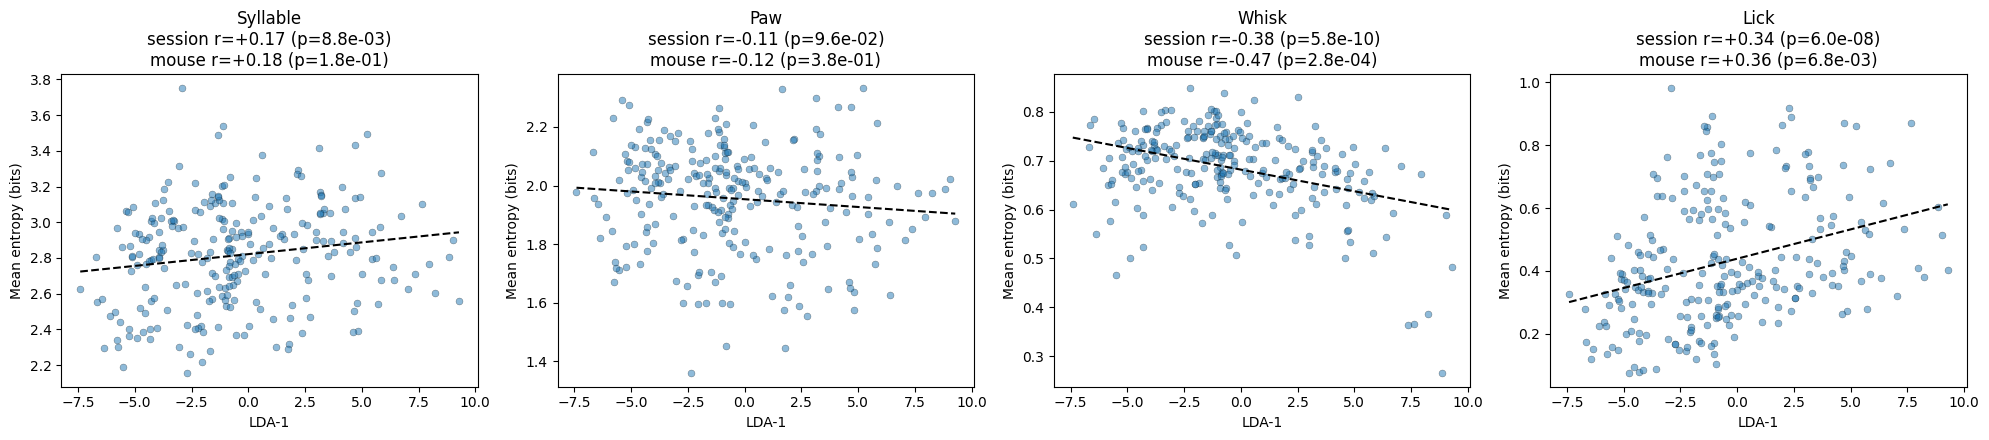

In [116]:
from scipy.stats import pearsonr, spearmanr

# Per-session mean entropy per component
ent_df = pd.DataFrame({'session': pd.unique(sessions)})
for comp in components:
    ent_df[comp] = np.nanmean(entropy_by_comp[comp], axis=1)

lda = pd.read_pickle(prefix + 'representation_learning_variability/paper-individuality/'
                     'clustering/mouse_LDA_5_bins_cut06-07-2026').rename(columns={0: 'lda_1'})
m = ent_df.merge(lda[['session', 'lda_1', 'mouse_name']], on='session', how='inner')
per_mouse = m.groupby('mouse_name').mean(numeric_only=True)

fig, axes = plt.subplots(1, len(components), figsize=(5 * len(components), 4.5), sharex=True)
for ax, comp in zip(axes, components):
    x, y = m['lda_1'].values, m[comp].values
    msk = np.isfinite(x) & np.isfinite(y)
    ax.scatter(x[msk], y[msk], s=25, alpha=0.5, edgecolors='k', linewidths=0.3)
    r, p = pearsonr(x[msk], y[msk])
    xm, ym = per_mouse['lda_1'].values, per_mouse[comp].values
    mmsk = np.isfinite(xm) & np.isfinite(ym)
    rm, pm = pearsonr(xm[mmsk], ym[mmsk])
    z = np.polyfit(x[msk], y[msk], 1)
    xl = np.linspace(x[msk].min(), x[msk].max(), 100)
    ax.plot(xl, np.polyval(z, xl), 'k--', lw=1.5)
    ax.set_title(f'{comp}\nsession r={r:+.2f} (p={p:.1e})\nmouse r={rm:+.2f} (p={pm:.1e})')
    ax.set_xlabel('LDA-1')
    ax.set_ylabel('Mean entropy (bits)')
plt.tight_layout()
plt.show()

# Does Fano factor track syllable-use entropy?

Here we ignore trial *phase* and instead put two time-resolved quantities on a common
**goCue-aligned time axis** (the neural grid, -0.5..1.0 s, ~16.7 ms bins) and ask, sample by
sample, whether neural variability tracks behavioural syllable entropy:

* **FF(t)** — the condition-adjusted single-neuron Fano factor time course recomputed from the
  firing-rate files exactly as in `neural/fano_factor/ff_psth_ldabin.ipynb` (causal ~100 ms
  smoothing, side x contrast residual variance / mean, per region with >=15 neurons, then
  averaged across regions within a session).
* **H(t)** — syllable-use entropy in the *same* timebin, computed from the goCue-aligned
  behavioural state files (`data/states_files/8_states_file_*`), whose 60 Hz `Bin` grid matches
  the neural bin width.

Each **(session, timebin)** is one sample; we correlate FF against entropy across all samples,
independent of when in the trial the timebin falls.

In [117]:
import pickle, os
from scipy.ndimage import uniform_filter1d
from iblatlas.regions import BrainRegions
from scipy.stats import pearsonr, spearmanr, ttest_1samp

fr_dir     = prefix + 'representation_learning_variability/paper-individuality/data/firing_rates/'
states_dir = prefix + 'representation_learning_variability/paper-individuality/data/states_files/'

# --- FF params (mirror ff_psth_ldabin.ipynb) ---
DROP=['root','void']; MIN_NEURONS=15; REMOVE_CONDITION=True; WIN_BINS=6
SMOOTH_MODE='causal'; MIN_MEAN_COUNT=0.01; REGION_LEVEL='cosmos'
br = BrainRegions()

# --- neural time grid + bin edges to map behaviour onto it ---
pkl = sorted(f for f in os.listdir(fr_dir) if f.startswith('firing_rate_'))
s0 = pickle.load(open(fr_dir + pkl[0], 'rb'))
tcols = sorted((c for c in s0.columns if c.startswith('t_')), key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols]); T = len(tcols)
binwidth = float(np.median(np.diff(tsec)))
edges = np.concatenate([[tsec[0]-binwidth/2], (tsec[:-1]+tsec[1:])/2, [tsec[-1]+binwidth/2]])
print(f'{T} neural timebins, {binwidth*1e3:.1f} ms each, {tsec[0]}..{tsec[-1]} s')

90 neural timebins, 17.0 ms each, -0.5..1.0 s


## FF(t): recompute the Fano-factor time course per session

In [118]:
def _smooth_time(A, W, mode):
    if mode == 'centered':
        return uniform_filter1d(A, W, axis=2, mode='nearest')
    c = np.cumsum(A, axis=2); out = np.empty_like(A)
    out[..., :W] = c[..., :W] / np.arange(1, W + 1); out[..., W:] = (c[..., W:] - c[..., :-W]) / W
    return out

def _ff_curve(A, cond):
    mean = np.nanmean(A, axis=1)
    if REMOVE_CONDITION and cond is not None:
        resid = A.astype(float).copy()
        for cc in pd.unique(cond):
            ci = np.where(cond == cc)[0]; resid[:, ci, :] -= np.nanmean(A[:, ci, :], axis=1, keepdims=True)
        var = np.nanvar(resid, axis=1, ddof=1)
    else:
        var = np.nanvar(A, axis=1, ddof=1)
    with np.errstate(invalid='ignore', divide='ignore'):
        ff = var / (mean + 1e-6)
    ff[(mean <= MIN_MEAN_COUNT) | ~np.isfinite(ff)] = np.nan
    return np.nanmean(ff, axis=0)

ff_region = {}   # (session, region) -> FF curve, keeping the region grouping
for i, fn in enumerate(pkl):
    try:
        d = pickle.load(open(fr_dir + fn, 'rb')); d = d[~d['area'].isin(DROP)]
        if len(d) == 0: continue
        session = d['session'].iloc[0]
        d = d.copy(); d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        neurons = sorted(d['nuid'].unique()); nidx = {n: k for k, n in enumerate(neurons)}
        trials = sorted(d['trial_id'].unique()); tix = {t: k for k, t in enumerate(trials)}
        A = np.full((len(neurons), len(trials), T), np.nan)
        A[d['nuid'].map(nidx).values, d['trial_id'].map(tix).values, :] = d[tcols].values * binwidth
        na = d.groupby('nuid')['area'].first().reindex(neurons)
        if REGION_LEVEL == 'cosmos':
            cmap = dict(zip(na.dropna().unique(), br.acronym2acronym(na.dropna().unique(), mapping='Cosmos')))
            na = na.map(cmap)
        neu_area = na.values
        conds = d.drop_duplicates('trial_id').set_index('trial_id')['condition'].reindex(trials).values
        vi = np.arange(len(trials))
        for region in pd.unique(neu_area):
            if region is None or (isinstance(region, float) and np.isnan(region)): continue
            ni = np.where(neu_area == region)[0]
            if len(ni) < MIN_NEURONS: continue
            Aw = _smooth_time(A[ni], WIN_BINS, SMOOTH_MODE) * WIN_BINS
            _c = _ff_curve(Aw[:, vi, :], conds[vi])
            _k = (session, region)   # pool probes of the same session-region by averaging
            ff_region[_k] = np.nanmean([ff_region[_k], _c], axis=0) if _k in ff_region else _c
        if (i + 1) % 100 == 0: print(f'  FF {i+1}/{len(pkl)}')
    except Exception as e:
        print('FF err', fn, e)

from collections import defaultdict
_by_sess = defaultdict(list)
for (s, reg), c in ff_region.items():
    _by_sess[s].append(c)
ff_t = {s: np.nanmean(np.vstack(v), axis=0) for s, v in _by_sess.items()}   # region-averaged, for the pooled analysis above
print(f'FF(t) computed for {len(ff_t)} sessions, {len(ff_region)} session-regions')

/tmp/ipykernel_21912/216748239.py:13: RuntimeWarning: Mean of empty slice
  ci = np.where(cond == cc)[0]; resid[:, ci, :] -= np.nanmean(A[:, ci, :], axis=1, keepdims=True)


  FF 100/380
  FF 200/380


/tmp/ipykernel_21912/216748239.py:13: RuntimeWarning: Mean of empty slice
  ci = np.where(cond == cc)[0]; resid[:, ci, :] -= np.nanmean(A[:, ci, :], axis=1, keepdims=True)


  FF 300/380


/tmp/ipykernel_21912/216748239.py:13: RuntimeWarning: Mean of empty slice
  ci = np.where(cond == cc)[0]; resid[:, ci, :] -= np.nanmean(A[:, ci, :], axis=1, keepdims=True)
/tmp/ipykernel_21912/216748239.py:13: RuntimeWarning: Mean of empty slice
  ci = np.where(cond == cc)[0]; resid[:, ci, :] -= np.nanmean(A[:, ci, :], axis=1, keepdims=True)


FF(t) computed for 238 sessions, 520 session-regions


## H(t): syllable entropy on the same goCue-aligned grid

In [119]:
def _cat_entropy(codes, n):
    codes = codes[np.isfinite(codes)].astype(int)
    return np.nan if codes.size == 0 else shannon_entropy(np.bincount(codes, minlength=n), base=2)

sfiles = [f for f in os.listdir(states_dir) if f.startswith('8_states_file_')]
entH = {c: {} for c in components}; mouse_of = {}
for j, f in enumerate(sfiles):
    try:
        df = pd.read_parquet(states_dir + f,
                             columns=['Bin', 'most_likely_states', 'goCueTrigger_times', 'mouse_name', 'session'])
        session = df['session'].iloc[0]; mouse_of[session] = df['mouse_name'].iloc[0]
        df = df.dropna(subset=['goCueTrigger_times', 'most_likely_states'])
        trel = (df['Bin'] - df['goCueTrigger_times']).values
        keep = (trel >= edges[0]) & (trel < edges[-1])
        bidx = np.digitize(trel[keep], edges) - 1
        codes = df['most_likely_states'].values[keep]
        H = {c: np.full(T, np.nan) for c in components}
        for b in range(T):
            cc = codes[bidx == b]
            if cc.size == 0: continue
            for comp, (decode, ncat) in components.items():
                H[comp][b] = _cat_entropy(decode(cc), ncat)
        for comp in components: entH[comp][session] = H[comp]
        if (j + 1) % 100 == 0: print(f'  H {j+1}/{len(sfiles)}')
    except Exception as e:
        print('H err', f, e)
print(f'H(t) computed for {len(entH["Syllable"])} sessions')

  H 100/318
  H 200/318
  H 300/318
H(t) computed for 318 sessions


## Correlate FF(t) against syllable entropy(t), pooled over (session, timebin)

In [120]:
# sessions with BOTH neural FF and behaviour, after the same QC as above
common = [s for s in ff_t if s in entH['Syllable'] and s not in prob_sessions]
rows = []
for s in common:
    for b in range(T):
        rec = dict(session=s, mouse_name=mouse_of.get(s), t=tsec[b], ff=ff_t[s][b])
        for comp in components: rec[comp] = entH[comp][s][b]
        rows.append(rec)
long = pd.DataFrame(rows)
print(f'{len(common)} sessions, {len(long)} (session, timebin) samples')

def _corr(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    return (*pearsonr(x[m], y[m]), *spearmanr(x[m], y[m]), int(m.sum()))

print('\nPooled over all (session, timebin) samples:')
for comp in components:
    r, p, rs, ps, n = _corr(long['ff'].values, long[comp].values)
    print(f'  FF vs {comp:9s} entropy:  Pearson r={r:+.3f} (p={p:.1e})   Spearman rho={rs:+.3f} (p={ps:.1e})')

# within-session correlation over timebins (does FF track entropy *within* a session's time course?)
wr = []
for s, g in long.groupby('session'):
    x, y = g['ff'].values, g['Syllable'].values; m = np.isfinite(x) & np.isfinite(y)
    if m.sum() > 10: wr.append(pearsonr(x[m], y[m])[0])
wr = np.array(wr)
t = ttest_1samp(wr, 0)
print(f'\nWithin-session FF vs Syllable-entropy correlation (n={len(wr)} sessions):')
print(f'  mean r={wr.mean():+.3f}, median r={np.median(wr):+.3f}, '
      f'frac r<0={np.mean(wr < 0):.2f}, one-sample t p={t.pvalue:.1e}')

238 sessions, 21420 (session, timebin) samples

Pooled over all (session, timebin) samples:
  FF vs Syllable  entropy:  Pearson r=-0.097 (p=3.0e-46)   Spearman rho=-0.047 (p=6.6e-12)
  FF vs Paw       entropy:  Pearson r=-0.156 (p=2.8e-116)   Spearman rho=-0.091 (p=2.6e-40)
  FF vs Whisk     entropy:  Pearson r=+0.166 (p=4.3e-132)   Spearman rho=+0.155 (p=5.5e-116)
  FF vs Lick      entropy:  Pearson r=-0.045 (p=3.3e-11)   Spearman rho=-0.006 (p=4.0e-01)

Within-session FF vs Syllable-entropy correlation (n=238 sessions):
  mean r=-0.149, median r=-0.183, frac r<0=0.84, one-sample t p=1.1e-27


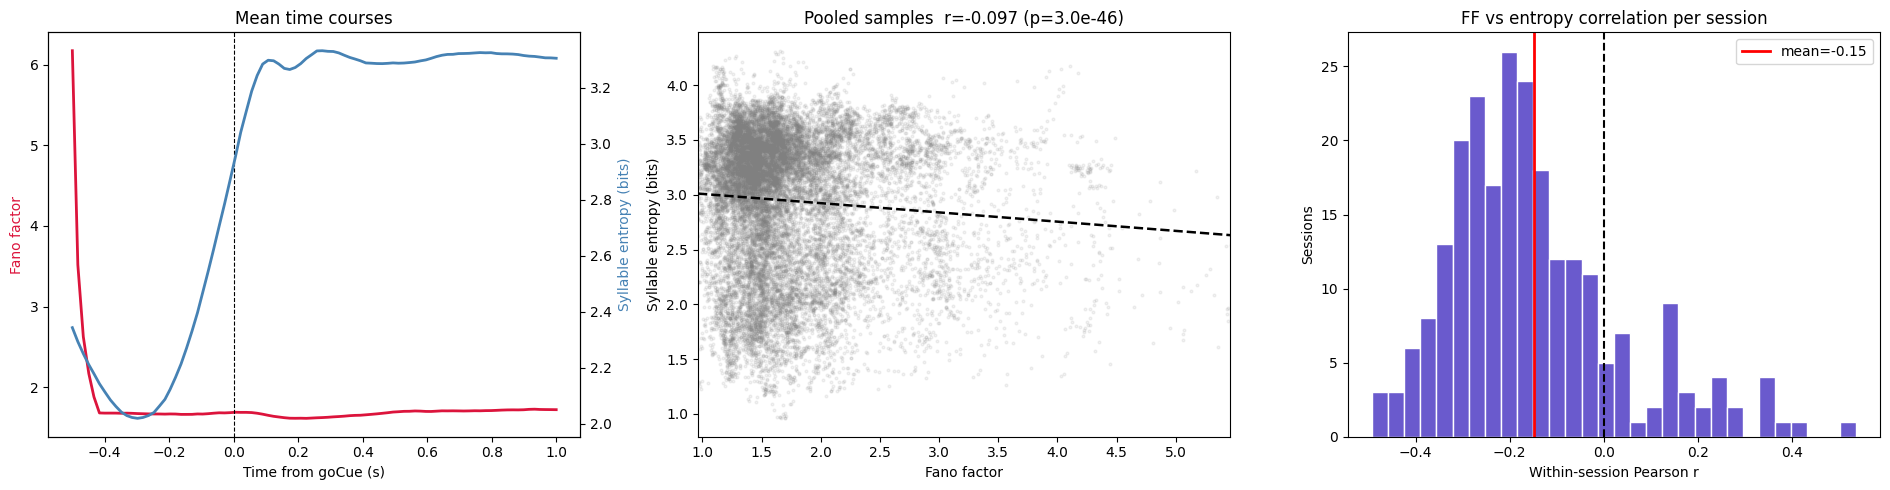

In [121]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# (1) mean FF(t) and mean H(t) on a twin axis -- visual overlay of the two time courses
mff = long.groupby('t')['ff'].mean()
mh  = long.groupby('t')['Syllable'].mean()
ax = axes[0]; ax2 = ax.twinx()
ax.plot(mff.index, mff.values, color='crimson', lw=2, label='FF')
ax2.plot(mh.index, mh.values, color='steelblue', lw=2, label='Syllable entropy')
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.set_xlabel('Time from goCue (s)'); ax.set_ylabel('Fano factor', color='crimson')
ax2.set_ylabel('Syllable entropy (bits)', color='steelblue')
ax.set_title('Mean time courses')

# (2) pooled scatter FF vs entropy
ax = axes[1]
x, y = long['ff'].values, long['Syllable'].values; m = np.isfinite(x) & np.isfinite(y)
ax.scatter(x[m], y[m], s=4, alpha=0.1, color='grey')
r, p, *_ = _corr(x, y)
z = np.polyfit(x[m], y[m], 1); xl = np.linspace(np.nanpercentile(x, 1), np.nanpercentile(x, 99), 100)
ax.plot(xl, np.polyval(z, xl), 'k--', lw=1.8)
ax.set_xlim(np.nanpercentile(x, 1), np.nanpercentile(x, 99))
ax.set_xlabel('Fano factor'); ax.set_ylabel('Syllable entropy (bits)')
ax.set_title(f'Pooled samples  r={r:+.3f} (p={p:.1e})')

# (3) within-session correlation distribution
ax = axes[2]
ax.hist(wr, bins=30, color='slateblue', edgecolor='white')
ax.axvline(0, color='k', ls='--'); ax.axvline(wr.mean(), color='red', lw=2, label=f'mean={wr.mean():+.2f}')
ax.set_xlabel('Within-session Pearson r'); ax.set_ylabel('Sessions')
ax.set_title('FF vs entropy correlation per session'); ax.legend()
plt.tight_layout(); plt.show()

## Proper test: region-level FF with nested random effects (mouse / session / region)

The pooled correlation above treats all 21,420 (session, timebin) samples as independent, which
is pseudoreplication: timebins are autocorrelated, every region in a session shares the same
behavioural entropy, and sessions nest within mice. Here we keep FF at the **region** level
(`ff_region`) and account for the grouping two ways:

1. **Linear mixed model** `FF ~ entropy + (1|mouse) + (1|session) + (1|session:region)` (both
   variables z-scored, so the fixed-effect slope is on the scale of a partial correlation).
2. **Two-stage effect size** — one Fisher-z-transformed FF-vs-entropy correlation *per
   session-region* (over its 90 timebins), then a mixed model `z ~ 1 + (1|mouse/session)`
   testing whether the mean coupling differs from zero. This is robust to timebin
   autocorrelation because each session-region contributes a single effect size.

In [122]:
import statsmodels.formula.api as smf

# region-level long table: (mouse, session, region, timebin)
rows_r = []
for (session, region), ff in ff_region.items():
    if session in prob_sessions or session not in entH['Syllable']:
        continue
    for b in range(T):
        rec = dict(mouse=mouse_of.get(session), session=session, region=region, t=tsec[b], ff=ff[b])
        for comp in components:
            rec[comp] = entH[comp][session][b]
        rows_r.append(rec)
long_r = pd.DataFrame(rows_r).dropna(subset=['ff', 'Syllable'])
long_r['sess_region'] = long_r['session'] + '__' + long_r['region']

# z-score FF and each entropy so the LMM slope approximates a partial correlation
_z = lambda s: (s - s.mean()) / s.std()
long_r['ff_z'] = _z(long_r['ff'])
for comp in components:
    long_r[comp + '_z'] = _z(long_r[comp])

print(f'{len(long_r)} rows | {long_r.mouse.nunique()} mice | {long_r.session.nunique()} sessions | '
      f'{long_r.sess_region.nunique()} session-regions | regions: {sorted(long_r.region.unique())}')

46800 rows | 56 mice | 238 sessions | 520 session-regions | regions: ['CB', 'CNU', 'CTXsp', 'HB', 'HPF', 'HY', 'Isocortex', 'MB', 'OLF', 'TH']


In [123]:
print('LINEAR MIXED MODEL:  ff_z ~ entropy_z + (1|mouse) + (1|session) + (1|session:region)\n')
for comp in components:
    md_ = smf.mixedlm(f'ff_z ~ {comp}_z', long_r, groups=long_r['mouse'],
                      vc_formula={'session': '0 + C(session)', 'sessregion': '0 + C(sess_region)'})
    res = md_.fit(method='lbfgs', maxiter=200)
    b = res.params[comp + '_z']; se = res.bse[comp + '_z']; p = res.pvalues[comp + '_z']
    print(f'  FF vs {comp:9s}: beta={b:+.4f}  SE={se:.4f}  z={b/se:+.2f}  p={p:.2e}')

LINEAR MIXED MODEL:  ff_z ~ entropy_z + (1|mouse) + (1|session) + (1|session:region)

  FF vs Syllable : beta=-0.1195  SE=0.0035  z=-34.60  p=2.89e-262
  FF vs Paw      : beta=-0.1471  SE=0.0033  z=-44.36  p=0.00e+00
  FF vs Whisk    : beta=+0.1368  SE=0.0037  z=+37.02  p=5.96e-300
  FF vs Lick     : beta=-0.0935  SE=0.0034  z=-27.51  p=1.35e-166


In [124]:
print('TWO-STAGE EFFECT SIZE:  one Fisher-z corr per session-region, then z ~ 1 + (1|mouse/session)\n')
twostage = {}
for comp in components:
    er = []
    for (s, reg), g in long_r.groupby(['session', 'region']):
        x, y = g['ff'].values, g[comp].values; msk = np.isfinite(x) & np.isfinite(y)
        if msk.sum() > 10 and x[msk].std() > 0 and y[msk].std() > 0:
            r = np.clip(pearsonr(x[msk], y[msk])[0], -0.999, 0.999)
            er.append(dict(mouse=g['mouse'].iloc[0], session=s, z=np.arctanh(r)))
    ez = pd.DataFrame(er)
    res = smf.mixedlm('z ~ 1', ez, groups=ez['mouse'], vc_formula={'session': '0 + C(session)'}).fit(method='lbfgs')
    mean_r = np.tanh(res.params['Intercept']); p = res.pvalues['Intercept']
    twostage[comp] = (mean_r, p, len(ez))
    print(f'  FF vs {comp:9s}: mean r={mean_r:+.3f}  (p={p:.2e}, n={len(ez)} session-regions)')

TWO-STAGE EFFECT SIZE:  one Fisher-z corr per session-region, then z ~ 1 + (1|mouse/session)



/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1533: RuntimeWarning: divide by zero encountered in log
  cov_aug_logdet = cov_re_logdet + np.sum(np.log(vc_var))
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1537: RuntimeWarning: divide by zero encountered in divide
  solver = _smw_solver(1., ex_r, ex2_r, cov_re_inv, 1 / vc_var)
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1542: RuntimeWarning: divide by zero encountered in divide
  ld = _smw_logdet(1., ex_r, ex2_r, cov_re_inv, 1 / vc_var,
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:573: RuntimeWarning: invalid value encountered in scalar add
  return B_logdet + ld + ld1
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarn

  FF vs Syllable : mean r=-0.148  (p=2.66e-04, n=520 session-regions)


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1533: RuntimeWarning: divide by zero encountered in log
  cov_aug_logdet = cov_re_logdet + np.sum(np.log(vc_var))
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1537: RuntimeWarning: divide by zero encountered in divide
  solver = _smw_solver(1., ex_r, ex2_r, cov_re_inv, 1 / vc_var)
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1542: RuntimeWarning: divide by zero encountered in divide
  ld = _smw_logdet(1., ex_r, ex2_r, cov_re_inv, 1 / vc_var,
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:573: RuntimeWarning: inval

  FF vs Paw      : mean r=-0.195  (p=1.15e-62, n=520 session-regions)
  FF vs Whisk    : mean r=+0.172  (p=1.23e-06, n=520 session-regions)
  FF vs Lick     : mean r=-0.119  (p=8.81e-03, n=520 session-regions)


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1533: RuntimeWarning: divide by zero encountered in log
  cov_aug_logdet = cov_re_logdet + np.sum(np.log(vc_var))
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1537: RuntimeWarning: divide by zero encountered in divide
  solver = _smw_solver(1., ex_r, ex2_r, cov_re_inv, 1 / vc_var)
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1542: RuntimeWarning: divide by zero encountered in divide
  ld = _smw_logdet(1., ex_r, ex2_r, cov_re_inv, 1 / vc_var,
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/sta

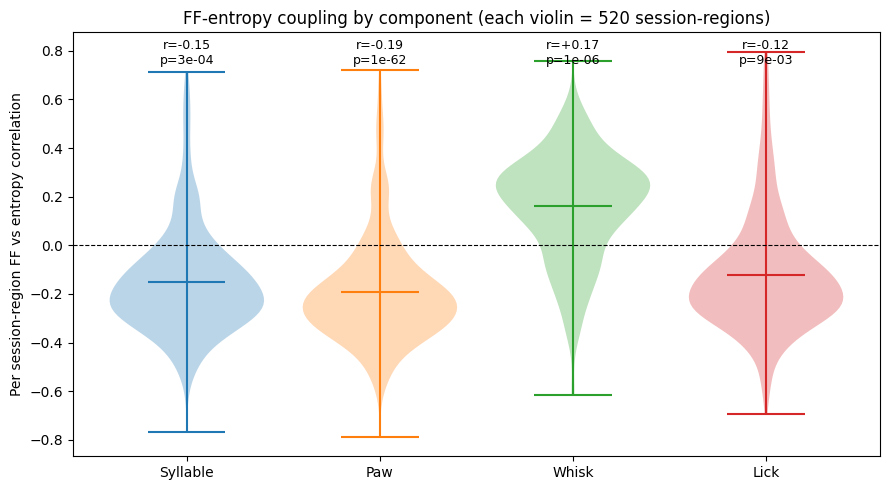

In [125]:
# Visualise the grouped effect sizes: distribution of per-session-region correlations per component
fig, ax = plt.subplots(figsize=(9, 5))
pos = np.arange(len(components))
for i, comp in enumerate(components):
    rs = []
    for (s, reg), g in long_r.groupby(['session', 'region']):
        x, y = g['ff'].values, g[comp].values; msk = np.isfinite(x) & np.isfinite(y)
        if msk.sum() > 10 and x[msk].std() > 0 and y[msk].std() > 0:
            rs.append(pearsonr(x[msk], y[msk])[0])
    ax.violinplot(rs, positions=[i], showmeans=True, widths=0.8)
    mean_r, p, n = twostage[comp]
    ax.text(i, 0.85, f'r={mean_r:+.2f}\np={p:.0e}', ha='center', va='top', fontsize=9)
ax.axhline(0, color='k', ls='--', lw=0.8)
ax.set_xticks(pos); ax.set_xticklabels(list(components))
ax.set_ylabel('Per session-region FF vs entropy correlation')
ax.set_title('FF-entropy coupling by component (each violin = 520 session-regions)')
plt.tight_layout(); plt.show()

## Removing the stimulus-locking confound: pre-stimulus period only

In the full window both FF and entropy are locked to goCue (FF quenches, movement entropy rises
at t=0), so part of the correlation is just shared event-locking rather than genuine tracking.
Restricting to **t < 0 (before goCue)** removes the stimulus transient: any coupling that remains
is moment-to-moment co-fluctuation during the quiescence/baseline period, not a common response
to the stimulus. We rerun both the LMM and the honest two-stage effect size on this window.

In [126]:
pre = long_r[long_r['t'] < 0].copy()
print(f'pre-stimulus window: {pre["t"].nunique()} timebins ({pre["t"].min():.2f}..{pre["t"].max():.2f} s), {len(pre)} rows')

# re-z-score within the pre-stim subset
_z = lambda s: (s - s.mean()) / s.std()
pre['ff_z'] = _z(pre['ff'])
for comp in components:
    pre[comp + '_z'] = _z(pre[comp])

print('\nLMM  ff_z ~ entropy_z + (1|mouse)+(1|session)+(1|session:region):')
for comp in components:
    res = smf.mixedlm(f'ff_z ~ {comp}_z', pre, groups=pre['mouse'],
                      vc_formula={'session': '0 + C(session)', 'sessregion': '0 + C(sess_region)'}).fit(method='lbfgs', maxiter=200)
    b = res.params[comp + '_z']; se = res.bse[comp + '_z']; p = res.pvalues[comp + '_z']
    print(f'  FF vs {comp:9s}: beta={b:+.4f}  z={b/se:+.2f}  p={p:.2e}')

print('\nTwo-stage (honest):')
twostage_pre = {}
for comp in components:
    er = []
    for (s, reg), g in pre.groupby(['session', 'region']):
        x, y = g['ff'].values, g[comp].values; msk = np.isfinite(x) & np.isfinite(y)
        if msk.sum() > 10 and x[msk].std() > 0 and y[msk].std() > 0:
            er.append(dict(mouse=g['mouse'].iloc[0], session=s,
                           z=np.arctanh(np.clip(pearsonr(x[msk], y[msk])[0], -0.999, 0.999))))
    ez = pd.DataFrame(er)
    res = smf.mixedlm('z ~ 1', ez, groups=ez['mouse'], vc_formula={'session': '0 + C(session)'}).fit(method='lbfgs')
    twostage_pre[comp] = (np.tanh(res.params['Intercept']), res.pvalues['Intercept'], len(ez))
    print(f'  FF vs {comp:9s}: mean r={twostage_pre[comp][0]:+.3f}  p={twostage_pre[comp][1]:.2e}  (n={len(ez)} sess-regions)')

pre-stimulus window: 30 timebins (-0.50..-0.01 s), 15600 rows

LMM  ff_z ~ entropy_z + (1|mouse)+(1|session)+(1|session:region):
  FF vs Syllable : beta=+0.0717  z=+6.32  p=2.64e-10
  FF vs Paw      : beta=-0.0349  z=-3.90  p=9.58e-05
  FF vs Whisk    : beta=+0.6548  z=+37.54  p=1.85e-308
  FF vs Lick     : beta=+0.3850  z=+10.84  p=2.25e-27

Two-stage (honest):
  FF vs Syllable : mean r=+0.105  p=2.69e-09  (n=520 sess-regions)
  FF vs Paw      : mean r=+0.005  p=7.42e-01  (n=520 sess-regions)
  FF vs Whisk    : mean r=+0.309  p=9.95e-28  (n=520 sess-regions)
  FF vs Lick     : mean r=+0.267  p=1.27e-18  (n=464 sess-regions)


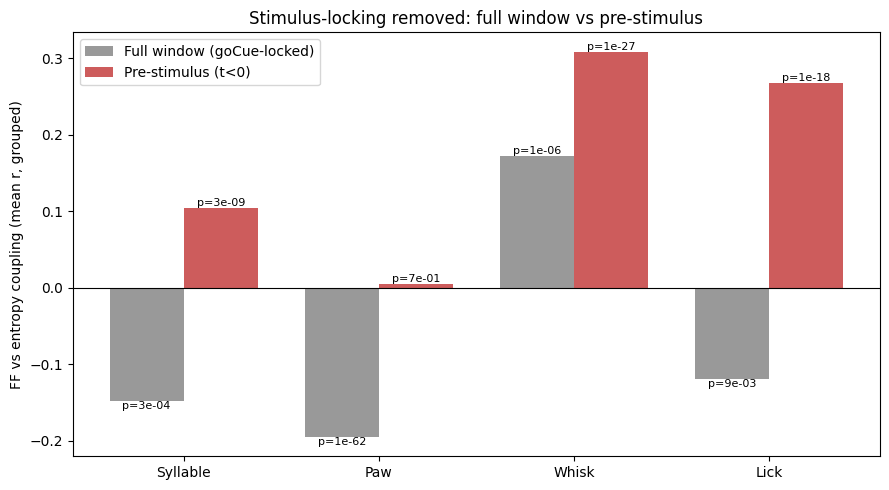

In [127]:
# Compare full-window vs pre-stimulus coupling side by side (two-stage effect sizes)
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(components)); w = 0.38
full_r = [twostage[c][0] for c in components]
pre_r  = [twostage_pre[c][0] for c in components]
ax.bar(x - w/2, full_r, w, label='Full window (goCue-locked)', color='0.6')
ax.bar(x + w/2, pre_r,  w, label='Pre-stimulus (t<0)', color='indianred')
for i, c in enumerate(components):
    ax.text(i - w/2, full_r[i], f'p={twostage[c][1]:.0e}', ha='center',
            va='bottom' if full_r[i] >= 0 else 'top', fontsize=8)
    ax.text(i + w/2, pre_r[i], f'p={twostage_pre[c][1]:.0e}', ha='center',
            va='bottom' if pre_r[i] >= 0 else 'top', fontsize=8)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(list(components))
ax.set_ylabel('FF vs entropy coupling (mean r, grouped)')
ax.set_title('Stimulus-locking removed: full window vs pre-stimulus')
ax.legend()
plt.tight_layout(); plt.show()

## Window-restricted analyses: pre-stimulus (-0.2..0 s) vs post-stimulus (0.1..0.3 s)

Both entropy-vs-LDA and FF-vs-entropy are recomputed separately in a pre-stimulus window
(-0.2..0 s, before goCue) and a post-stimulus window (0.1..0.3 s), on the goCue-aligned grid.
Per-session entropy in a window = mean of the per-timebin entropies over that window's bins.

In [128]:
PRE_WIN, POST_WIN = (-0.2, 0.0), (0.1, 0.3)
pre_bins  = (tsec >= PRE_WIN[0])  & (tsec < PRE_WIN[1])
post_bins = (tsec >= POST_WIN[0]) & (tsec < POST_WIN[1])
print(f'pre: {pre_bins.sum()} bins, post: {post_bins.sum()} bins')

# per-session window-mean entropy (entH covers all behavioural sessions)
ent_rows = []
for s in entH['Syllable']:
    if s in prob_sessions: continue
    rec = dict(session=s, mouse_name=mouse_of.get(s))
    for comp in components:
        rec[comp + '_pre']  = np.nanmean(entH[comp][s][pre_bins])
        rec[comp + '_post'] = np.nanmean(entH[comp][s][post_bins])
    ent_rows.append(rec)
ent_win = pd.DataFrame(ent_rows)

lda = pd.read_pickle(prefix + 'representation_learning_variability/paper-individuality/'
                     'clustering/mouse_LDA_5_bins_cut06-07-2026').rename(columns={0: 'lda_1'})
mw = ent_win.merge(lda[['session', 'lda_1']], on='session', how='inner')
mw_mouse = mw.groupby('mouse_name').mean(numeric_only=True)
print(f'{len(mw)} sessions merged with LDA')

pre: 12 bins, post: 12 bins
248 sessions merged with LDA


### (1) Syllable entropy vs LDA-1, pre- vs post-stimulus

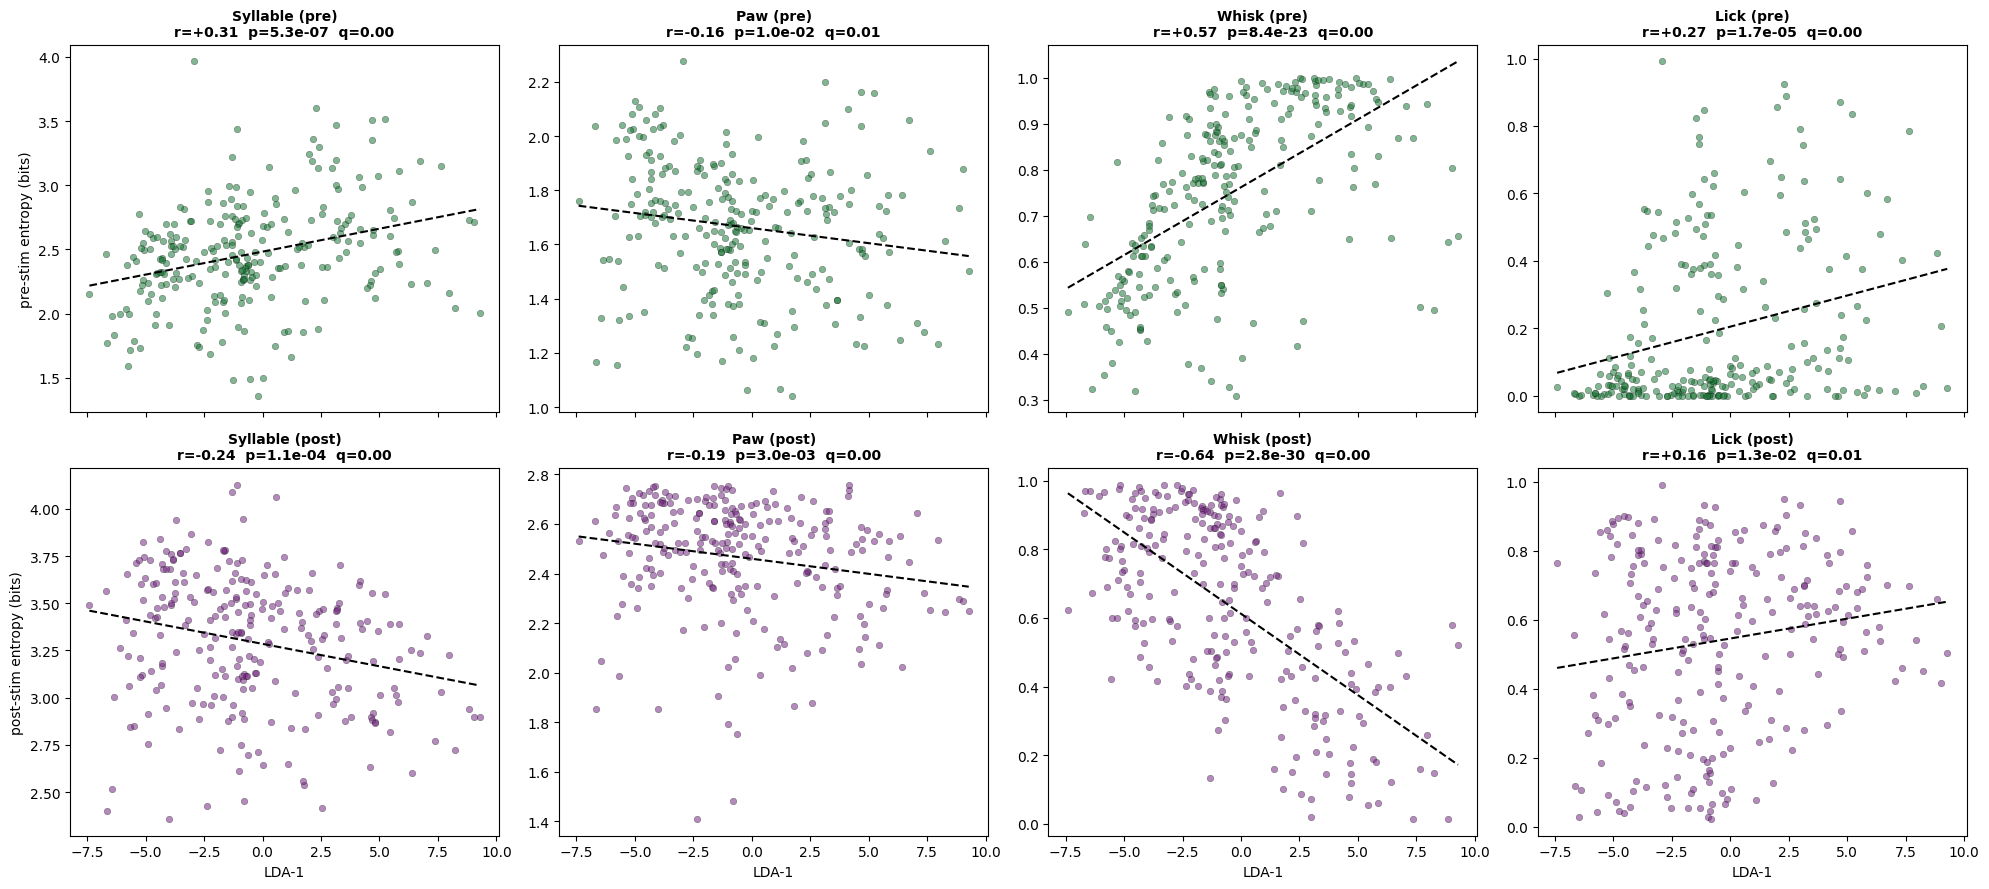

In [129]:
from statsmodels.stats.multitest import multipletests

# green (pre) / purple (post) -- avoid red/blue, which read as the LDA-1 (coolwarm) axis
WIN_COLOR = {'pre': '#1b7837', 'post': '#762a83'}

# --- pass 1: correlations + collect p-values for multiple-comparison correction ---
cstat = {}
for win in ['pre', 'post']:
    for comp in components:
        x, y = mw['lda_1'].values, mw[comp + '_' + win].values
        m = np.isfinite(x) & np.isfinite(y)
        r, p = pearsonr(x[m], y[m])
        cstat[(win, comp)] = dict(r=r, p=p)
keys = list(cstat)
qvals = multipletests([cstat[k]['p'] for k in keys], method='fdr_bh')[1]   # BH-FDR over the 8 tests
for k, q in zip(keys, qvals):
    cstat[k]['q'] = q

# --- pass 2: plot (significant = bold title) ---
fig, axes = plt.subplots(2, len(components), figsize=(5 * len(components), 9), sharex=True)
for row, win in enumerate(['pre', 'post']):
    for col, comp in enumerate(components):
        ax = axes[row, col]; ycol = comp + '_' + win
        x, y = mw['lda_1'].values, mw[ycol].values; msk = np.isfinite(x) & np.isfinite(y)
        ax.scatter(x[msk], y[msk], s=22, alpha=0.55, edgecolors='k', linewidths=0.3,
                   color=WIN_COLOR[win])
        z = np.polyfit(x[msk], y[msk], 1); xl = np.linspace(x[msk].min(), x[msk].max(), 100)
        ax.plot(xl, np.polyval(z, xl), 'k--', lw=1.5)
        st = cstat[(win, comp)]; sig = st['q'] < 0.05
        ax.set_title(f"{comp} ({win})\nr={st['r']:+.2f}  p={st['p']:.1e}  q={st['q']:.2f}",
                     fontsize=10, fontweight='bold' if sig else 'normal')
        if col == 0: ax.set_ylabel(f'{win}-stim entropy (bits)')
        if row == 1: ax.set_xlabel('LDA-1')
plt.tight_layout(); plt.show()

### (2) FF vs behavioural entropy per window, split by component (bin-level LMM)

Each **(session, region, timebin)** within a window is one sample. We fit
`FF_z ~ entropy_z + (1|mouse) + (1|session) + (1|session:region)` per component and window
(z-scored, so beta is on a partial-correlation scale). This uses every bin directly, so the
narrow 12-bin window is not a problem: the LMM pools across sessions/regions rather than relying
on a per-session-region correlation over 12 points.

[pre] 12 bins x 520 session-regions = 6240 samples
    FF vs Syllable : beta=+0.0210  SE=0.0032  p=3.71e-11
    FF vs Paw      : beta=+0.0164  SE=0.0025  p=3.57e-11
    FF vs Whisk    : beta=+0.0249  SE=0.0053  p=2.51e-06
    FF vs Lick     : beta=+0.0457  SE=0.0136  p=7.62e-04
[post] 12 bins x 520 session-regions = 6240 samples
    FF vs Syllable : beta=-0.0070  SE=0.0055  p=2.05e-01
    FF vs Paw      : beta=-0.0066  SE=0.0057  p=2.43e-01
    FF vs Whisk    : beta=+0.0457  SE=0.0054  p=3.55e-17
    FF vs Lick     : beta=-0.0234  SE=0.0038  p=5.34e-10


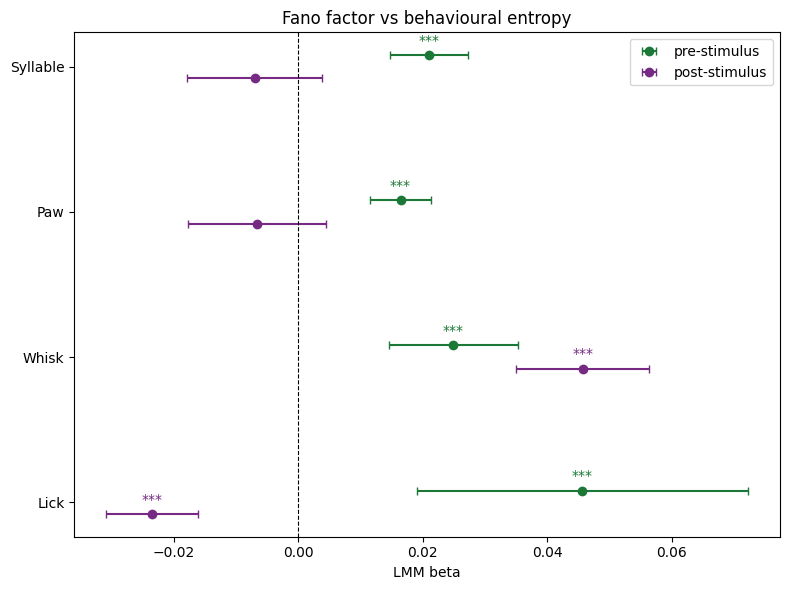

In [134]:
import statsmodels.formula.api as smf

long_r['sess_region'] = long_r['session'] + '__' + long_r['region']
windows = {'pre': pre_bins, 'post': post_bins}
lmm_beta = {w: {} for w in windows}; lmm_se = {w: {} for w in windows}; lmm_p = {w: {} for w in windows}
for w, bins in windows.items():
    sub = long_r[long_r['t'].isin(tsec[bins])].copy()
    _z = lambda s: (s - s.mean()) / s.std()
    sub['ff_z'] = _z(sub['ff'])
    for comp in components: sub[comp + '_z'] = _z(sub[comp])
    print(f'[{w}] {int(bins.sum())} bins x {sub.sess_region.nunique()} session-regions = {len(sub)} samples')
    for comp in components:
        res = smf.mixedlm(f'ff_z ~ {comp}_z', sub, groups=sub['mouse'],
                          vc_formula={'session': '0 + C(session)', 'sessregion': '0 + C(sess_region)'}
                          ).fit(method='lbfgs', maxiter=300)
        lmm_beta[w][comp] = res.params[comp + '_z']; lmm_se[w][comp] = res.bse[comp + '_z']
        lmm_p[w][comp] = res.pvalues[comp + '_z']
        print(f'    FF vs {comp:9s}: beta={lmm_beta[w][comp]:+.4f}  SE={lmm_se[w][comp]:.4f}  p={lmm_p[w][comp]:.2e}')

# ---- forest plot: LMM beta +/- 95% CI per component, pre vs post ----
fig, ax = plt.subplots(figsize=(8, 6))
yl = np.arange(len(components))[::-1]; off = 0.16
for k, (w, color) in enumerate([('pre', '#1b7837'), ('post', '#762a83')]):
    for y, comp in zip(yl, components):
        b = lmm_beta[w][comp]; ci = 1.96 * lmm_se[w][comp]
        yy = y + (0.5 - k) * off
        ax.errorbar(b, yy, xerr=ci, fmt='o', color=color, capsize=3,
                    label=f'{w}-stimulus' if comp == list(components)[0] else None)
        star = '***' if lmm_p[w][comp] < 1e-3 else ('**' if lmm_p[w][comp] < 1e-2 else ('*' if lmm_p[w][comp] < 0.05 else ''))
        if star: ax.text(b, yy + 0.05, star, ha='center', va='bottom', fontsize=10, color=color)
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.set_yticks(yl); ax.set_yticklabels(list(components))
ax.set_xlabel('LMM beta')  # : FF ~ entropy (partial-r scale, +/- 95% CI)
ax.set_title('Fano factor vs behavioural entropy')
ax.legend(loc='best')
plt.tight_layout(); plt.show()

### Partial-residual scatter: what the LMM slope sees

A raw FF-vs-entropy scatter is dominated by between-session/region baseline differences (the
random intercepts). To visualise the actual within-group coupling the LMM estimates, we remove
each session-region's mean from both FF and entropy and scatter the residuals, with the LMM
slope overlaid. Rows = window, columns = component.

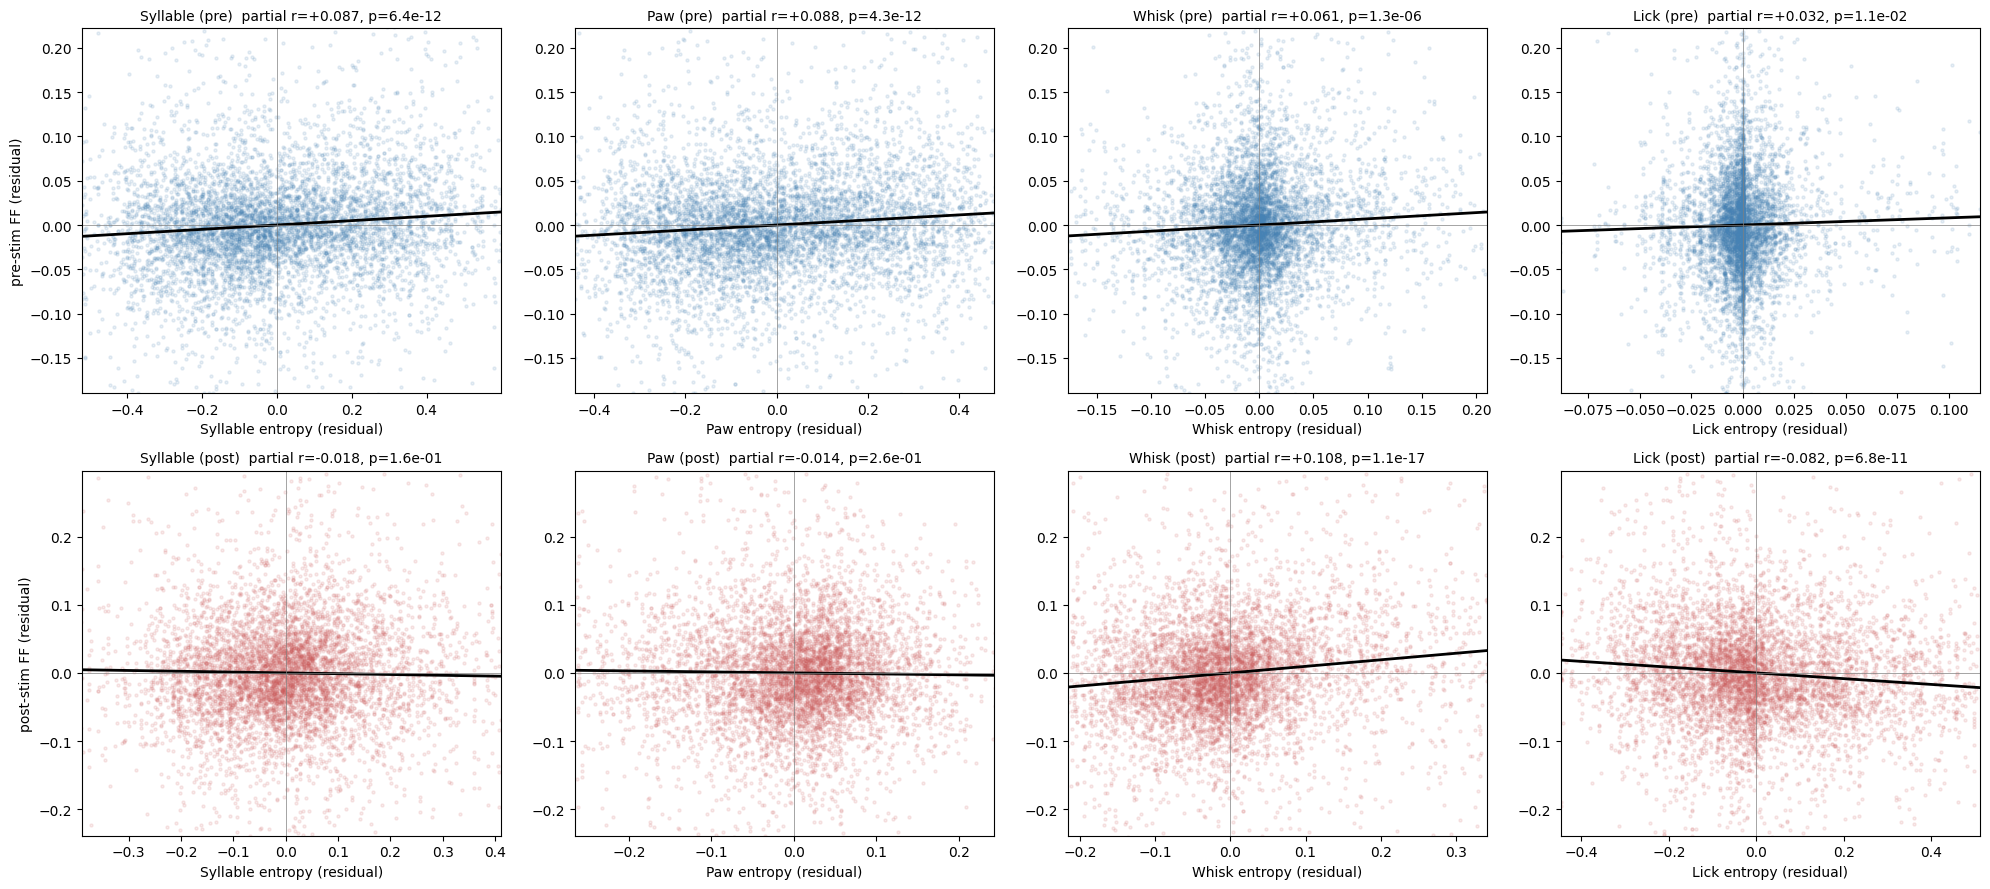

In [131]:
# Self-contained partial-residual scatter (does not depend on the forest cell's variables).
from scipy.stats import pearsonr

if 'sess_region' not in long_r.columns:
    long_r['sess_region'] = long_r['session'] + '__' + long_r['region']
_pre  = (tsec >= -0.2) & (tsec < 0.0)
_post = (tsec >= 0.1) & (tsec < 0.3)

def _demean(sub, cols):
    for c in cols:
        sub[c + '_r'] = sub[c] - sub.groupby('sess_region')[c].transform('mean')
    return sub

fig, axes = plt.subplots(2, len(components), figsize=(5 * len(components), 9))
for row, (w, bins) in enumerate([('pre', _pre), ('post', _post)]):
    sub = _demean(long_r[long_r['t'].isin(tsec[bins])].copy(), ['ff'] + list(components))
    for col, comp in enumerate(components):
        ax = axes[row, col]
        x, y = sub[comp + '_r'].values, sub['ff_r'].values
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3 or np.nanstd(x[m]) == 0:
            ax.set_title(f'{comp} ({w}): no data'); continue
        ax.scatter(x[m], y[m], s=5, alpha=0.12, color='steelblue' if w == 'pre' else 'indianred')
        # slope via least squares (guarded), and residual partial correlation for the title
        slope = np.linalg.lstsq(np.c_[x[m], np.ones(m.sum())], y[m], rcond=None)[0][0]
        r, p = pearsonr(x[m], y[m])
        lo, hi = np.nanpercentile(x[m], [1, 99])
        if hi > lo:
            xl = np.linspace(lo, hi, 100)
            ax.plot(xl, slope * xl + (y[m].mean() - slope * x[m].mean()), 'k-', lw=2)
            ax.set_xlim(lo, hi)
        ylo, yhi = np.nanpercentile(y[m], [1, 99])
        if yhi > ylo: ax.set_ylim(ylo, yhi)
        ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
        ax.set_title(f'{comp} ({w})  partial r={r:+.3f}, p={p:.1e}', fontsize=10)
        if col == 0: ax.set_ylabel(f'{w}-stim FF (residual)')
        ax.set_xlabel(f'{comp} entropy (residual)')
plt.tight_layout(); plt.show()